In [1]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import cmcrameri.cm as cm
import time
import torch
import torch.nn as nn
import torch.nn.functional as F

from tqdm import tqdm

from aidino.detector import Detector
from aidino.sample import Crystal, load_displacement_npz
from aidino.diffraction import BraggCoherentDiffraction
from aidino.beam import GaussianBeam
from aidino.plot_utils import format_axis
from aidino.xpcs import calculate_two_time_correlation, create_annulus_mask, draw_annulus_mask

In [2]:
dtype = torch.float32
device = 'cuda:0' if torch.cuda.is_available() else 'cpu'
torch.set_default_dtype(dtype)

In [101]:
wavelength = 1.55e-10

detector = Detector(
    num_pixels_i = 128,
    num_pixels_j = 128,
    pixel_size = 75e-6,
    distance = 0.1,
    wavelength = wavelength,
    dtype = dtype,
    device = device
)
resolution = detector.calculate_resolution()
print(f'Detector resolution (ΔX): {resolution:.2g} m')

crystal = Crystal(
    '../cifs/HfZrO4_KMC.cif',
    wavelength = wavelength,
    include_anomalous = True,
    dtype = dtype,
    device = device
)

simulator = BraggCoherentDiffraction(
    crystal = crystal
)

Detector resolution (ΔX): 1.6e-09 m


In [102]:
displacement_field = torch.from_numpy(np.load("../trajectories/HfZrO4_KMC_displacement_field.npz")["displacement_field"])

In [103]:
crystal.crystal_size = displacement_field.shape[1:4]

In [104]:
lengths = crystal.lattice_vectors.norm(dim=1)
crystal.print_size()

Crystal size: 14.6 nm x 14.5 nm x 4.5 nm


In [105]:
crystal.visualize_structure()

Display size reduced to (23, 24, 7) to stay within 50,000 atom display limit.
Visualizing crystal of size (23, 24, 7) (46368 atoms)


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

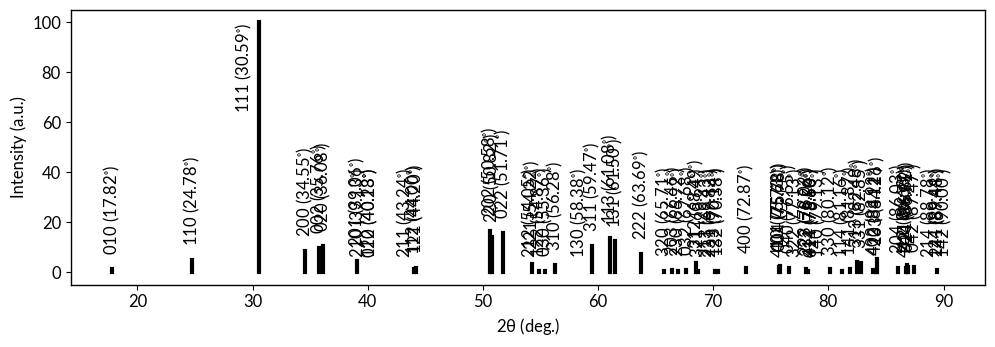

In [106]:
fig = crystal.get_xrd_pattern()

In [107]:
crystal.list_reflections()

  h   k   l     2θ (degrees)
-----------------------------------
  0   1   0        17.816349
  1   1   0        24.776626
  1   1   1        30.592998
  2   0   0        34.550607
  0   0   2        35.764820
  0   2   0        36.082628
  2   0   1        39.060475
  2   1   0        39.134391
  1   2   0        40.175240
  0   1   2        40.229380
  2   1   1        43.237251
  1   1   2        43.997398
  1   2   1        44.198357
  2   0   2        50.576425
  2   2   0        50.817389
  0   2   2        51.713703
  2   1   2        54.049185
  2   2   1        54.221747
  1   2   2        54.865505
  0   3   0        55.362727
  3   1   0        56.275530
  1   3   0        58.379844
  3   1   1        59.465613
  1   1   3        61.075945
  1   3   1        61.501144
  2   2   2        63.690687
  3   2   0        65.711837
  2   0   3        66.463890
  2   3   0        66.920705
  0   3   2        67.678585
  3   1   2        68.492531
  3   2   1        68.642764
  2   1

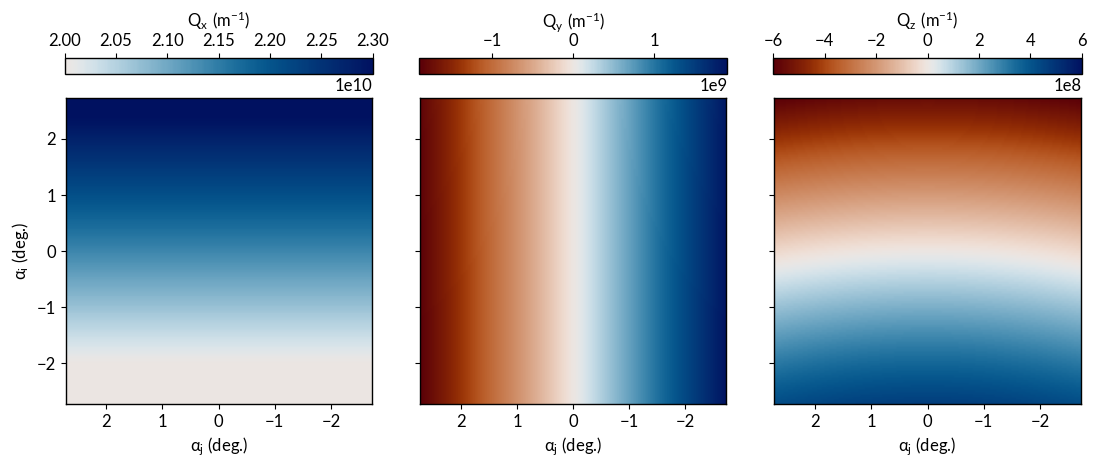

In [108]:
crystal.align_miller_plane_to_axis((1,1,1), target_axis='x')

theta_B = torch.deg2rad(torch.tensor(30.593 / 2., dtype=dtype, device=device))
k_i = torch.tensor([torch.sin(-theta_B), 0.0, torch.cos(-theta_B)], dtype=dtype, device=device)
k_f = torch.tensor([torch.sin(theta_B), 0.0, torch.cos(theta_B)], dtype=dtype, device=device)

q_vectors = detector.calculate_q_vectors(k_i, k_f)
fig = detector.plot_q_vectors(q_vectors)

In [109]:
# Require that supercell approximation remains below experiment resolution, i.e. d_i * a_i < ΔX
print('ΔX:', ','.join('{:d}'.format(int(resolution / lengths[i].item())) for i in range(len(lengths))), 'cells')
print('ΔX^3:', '{:d}'.format(np.prod([int(resolution / lengths[i].item()) for i in range(len(lengths))])), 'cells')
print('Oversampling ratio:', detector.calculate_oversampling_ratio(crystal.crystal_volume).item())

ΔX: 3,3,3 cells
ΔX^3: 27 cells
Oversampling ratio: 10.461690902709961


In [110]:
supercell_size = (2,1,3)
q_batch_size = 16

In [111]:
beam = GaussianBeam(
    wavelength = wavelength,
    fwhm = 100e-9
)

beam.create_profile(
    crystal = crystal,
    supercell_size = supercell_size,
    k_i = k_i
)

Auto beam entry: crystal +a face. beam_center = (27.0, 14.5, 4.5)


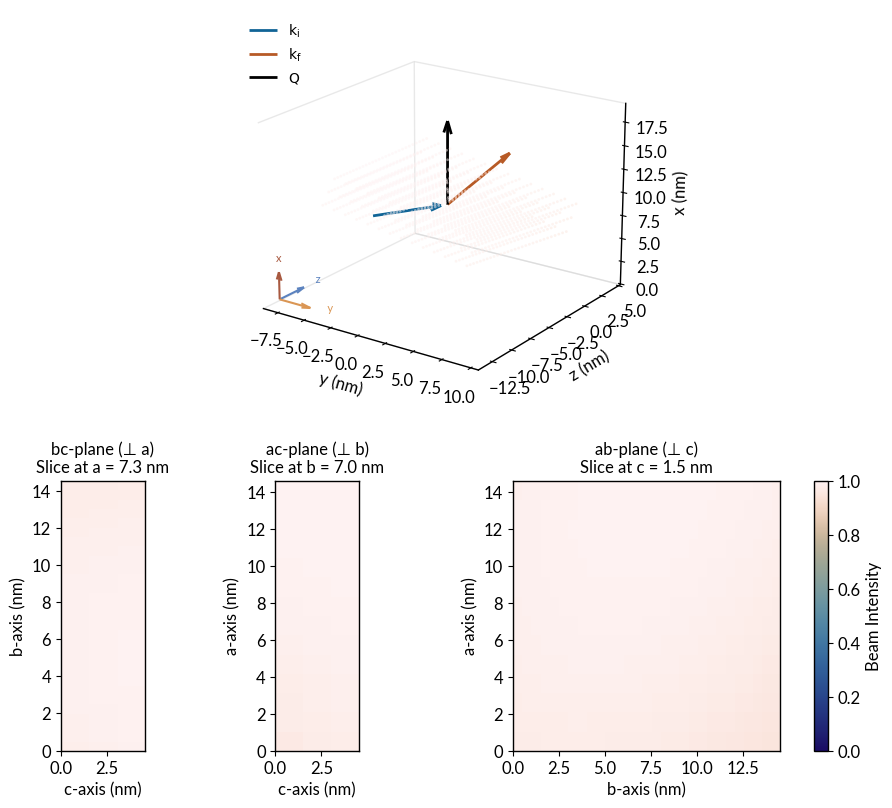

In [112]:
fig = beam.plot_profile(
    crystal = crystal,
    supercell_size = supercell_size,
    k_i = k_i,
    k_f = k_f
)

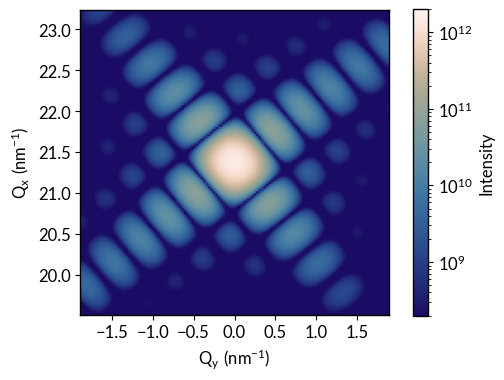

In [113]:
amplitude = simulator.calculate_supercell_scattering(q_vectors, supercell_size, mask=beam.profile, q_batch_size=q_batch_size)
intensity = (amplitude.abs() ** 2)
fig = detector.plot_intensity(intensity[0], q_vectors)

Execution time: 0.428 s
Peak GPU memory: 8.4 MB allocated


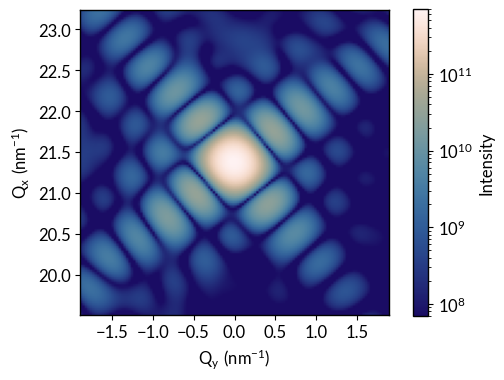

In [114]:
# Calculate intensity for a single timestep
timestep = 2000

if torch.cuda.is_available():
    torch.cuda.synchronize(device)
    baseline = torch.cuda.memory_allocated(device)
    torch.cuda.reset_peak_memory_stats(device)

t_start = time.time()
amplitude = simulator.calculate_supercell_scattering(q_vectors, supercell_size, q_batch_size=q_batch_size,
                                                     sublattice_displacement=displacement_field[[timestep]].to(device),
                                                     mask=beam.profile)
intensity = (amplitude.abs() ** 2)

if torch.cuda.is_available():
    torch.cuda.synchronize(device)
elapsed = time.time() - t_start

print(f'Execution time: {elapsed:.3f} s')
if torch.cuda.is_available():
    peak = torch.cuda.max_memory_allocated(device)
    delta = (peak - baseline) / 1024 ** 2
    print(f'Peak GPU memory: {delta:.1f} MB allocated')

fig = detector.plot_intensity(intensity[-1], q_vectors)

Execution time 44.22419881820679 s


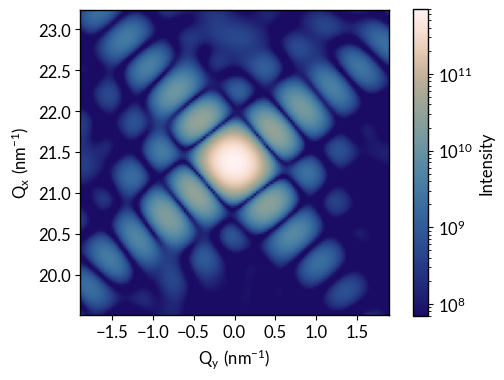

In [118]:
# Calculate intensity for all timesteps
t_start = time.time()
amplitude = simulator.calculate_supercell_scattering(q_vectors, supercell_size, q_batch_size=q_batch_size,
                                                     sublattice_displacement=displacement_field.to(device),
                                                     mask=beam.profile)
intensity = (amplitude.abs() ** 2)
print('Execution time', time.time() - t_start, 's')
fig = detector.plot_intensity(intensity[-1], q_vectors)

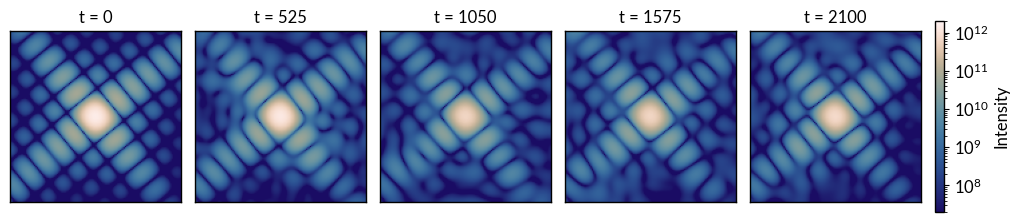

In [119]:
cmap = cm.lapaz
vmax = Detector.round_in_base(intensity[0].max().item(), digits=1)
vmin = vmax / 1e5 if vmax >= 1e5 else 1
norm = mpl.colors.LogNorm(vmin=vmin, vmax=vmax, clip=1)
sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)

fig, ax = plt.subplots(1,6, figsize=(10,2.5), gridspec_kw={'width_ratios':[1] * 5 + [0.05]})
fig.tight_layout()
fig.subplots_adjust(hspace=0.1, wspace=0.1)

for i, timestep in enumerate(np.linspace(0, len(intensity)-1, len(ax) - 1, dtype=int)):
    ax[i].imshow(intensity[timestep].cpu(), origin='lower', cmap=cmap, norm=norm)
    ax[i].set_xticks([])
    ax[i].set_yticks([])
    format_axis(ax[i], title=f't = {timestep}')

plt.colorbar(sm, cax=ax[-1])
format_axis(ax[-1], ylabel='Intensity')

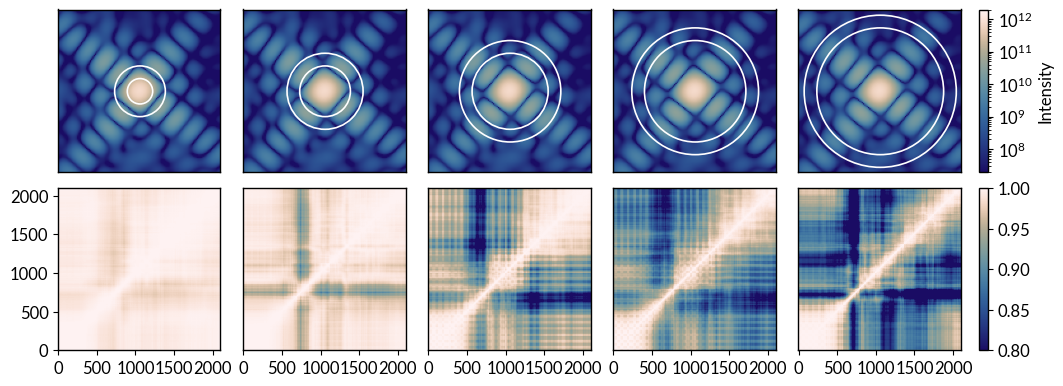

In [124]:
cmap = cm.lapaz
vmax = Detector.round_in_base(intensity[0].max().item(), digits=1)
vmin = vmax / 1e5 if vmax >= 1e5 else 1
norm = mpl.colors.LogNorm(vmin=vmin, vmax=vmax, clip=1)
sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)

norm_c2 = plt.Normalize(vmin=0.8, vmax=1.)
sm_c2 = mpl.cm.ScalarMappable(cmap=cmap, norm=norm_c2)

fig, ax = plt.subplots(2,6, figsize=(10,4), gridspec_kw={'width_ratios':[1] * 5 + [0.05]})
fig.tight_layout()
fig.subplots_adjust(hspace=0.1, wspace=0.1)

radii = intensity.shape[-1] // 2 // 6 * np.arange(1,6)
width = 10
for i in range(ax.shape[1] - 1):
    roi = create_annulus_mask(*intensity.shape[1:], radii[i], width)
    
    ax[0,i].imshow(intensity[-1].cpu(), cmap=cmap, norm=norm)
    draw_annulus_mask(
        ax[0,i],
        r_inner=radii[i],
        width=width,
        center=(intensity.shape[1] // 2,intensity.shape[2] // 2),
        lw=1.2,
        color="white",
    )
    
    ax[0,i].set_xticks([])
    ax[0,i].set_yticks([])
    
    C2 = calculate_two_time_correlation(intensity[:,roi].flatten(start_dim=1))
    ax[1,i].imshow(C2.cpu(), origin='lower', interpolation='none', cmap=cmap, norm=norm_c2)
    format_axis(ax[1,i], xbins=5, ybins=5)
    if i > 0:
        ax[1,i].set_yticks([])

plt.colorbar(sm, cax=ax[0,-1])
format_axis(ax[0,-1], ylabel='Intensity')

plt.colorbar(sm_c2, cax=ax[1,-1])
format_axis(ax[1,-1])